# Cobertura temporal por variable

Este notebook analiza la cobertura temporal del dataset final (`outputs/master_dataset.csv`):

1. Resumen por variable (nulos, primer/ultimo dato, gaps)
2. Visualizaciones de cobertura
3. Variables con huecos largos

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from pathlib import Path

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)

NOTEBOOK_DIR = Path.cwd()
DATASET_PATH = NOTEBOOK_DIR / 'outputs' / 'master_dataset.csv'
OUT_DIR = NOTEBOOK_DIR / 'outputs'
OUT_DIR.mkdir(exist_ok=True)

if not DATASET_PATH.exists():
    raise FileNotFoundError(f'No existe: {DATASET_PATH}')

df = pd.read_csv(DATASET_PATH, parse_dates=['Time'])
df = df.set_index('Time').sort_index()

print(f'Dataset: {DATASET_PATH}')
print(f'Shape: {df.shape}')
print(f'Rango temporal: {df.index.min()} -> {df.index.max()}')
print(f'Variables: {len(df.columns)}')


Dataset: \\wsl.localhost\Ubuntu\home\pablo_laptop\GIA\PIA\PIA_lab\sprint3\outputs\master_dataset.csv
Shape: (836681, 33)
Rango temporal: 2025-04-28 02:00:00 -> 2026-02-12 14:20:00
Variables: 33


In [2]:
def longest_gap(index_valid: pd.DatetimeIndex):
    if len(index_valid) < 2:
        return pd.NaT
    diffs = index_valid.to_series().diff().dropna()
    return diffs.max() if not diffs.empty else pd.NaT

def median_interval(index_valid: pd.DatetimeIndex):
    if len(index_valid) < 2:
        return pd.NaT
    diffs = index_valid.to_series().diff().dropna()
    return diffs.median() if not diffs.empty else pd.NaT

summary_rows = []
n_total = len(df)

for col in df.columns:
    s = df[col]
    valid_mask = s.notna()
    n_valid = int(valid_mask.sum())
    n_null = int((~valid_mask).sum())
    pct_null = (n_null / n_total) * 100 if n_total else np.nan

    if n_valid > 0:
        idx_valid = s.index[valid_mask]
        first_valid = idx_valid.min()
        last_valid = idx_valid.max()
        span_days = (last_valid - first_valid).total_seconds() / 86400
        max_gap = longest_gap(idx_valid)
        med_step = median_interval(idx_valid)
    else:
        first_valid = pd.NaT
        last_valid = pd.NaT
        span_days = np.nan
        max_gap = pd.NaT
        med_step = pd.NaT

    summary_rows.append({
        'variable': col,
        'n_valid': n_valid,
        'n_null': n_null,
        'pct_null': round(pct_null, 2),
        'first_valid': first_valid,
        'last_valid': last_valid,
        'coverage_span_days': round(span_days, 2) if pd.notna(span_days) else np.nan,
        'median_interval': med_step,
        'max_gap': max_gap,
    })

summary = pd.DataFrame(summary_rows).sort_values('pct_null', ascending=False)
summary.reset_index(drop=True, inplace=True)
display(summary)

summary.to_csv(OUT_DIR / 'coverage_summary.csv', index=False)
print(f'Guardado: {OUT_DIR / "coverage_summary.csv"}')


,variable,n_valid,n_null,pct_null,first_valid,last_valid,coverage_span_days,median_interval,max_gap
0,GPOA_mean,299285,537396,64.23,2025-06-18 14:00:00,2025-10-05 08:00:00,108.75,0 days 00:00:30,2 days 22:00:00
1,tracker_theta_theoretical_deg,423941,412740,49.33,2025-04-28 06:55:00,2026-02-12 14:20:00,290.31,0 days 00:00:30,0 days 14:53:00
2,Delta_Tsoil_S2,537166,299515,35.80,2025-07-17 02:00:00,2026-02-12 14:20:00,210.51,0 days 00:00:30,10 days 18:00:00
3,Delta_Tsoil_S1,537166,299515,35.80,2025-07-17 02:00:00,2026-02-12 14:20:00,210.51,0 days 00:00:30,10 days 18:00:00
4,Delta_VWC_S1,537166,299515,35.80,2025-07-17 02:00:00,2026-02-12 14:20:00,210.51,0 days 00:00:30,10 days 18:00:00
5,Delta_VWC_S2,537166,299515,35.80,2025-07-17 02:00:00,2026-02-12 14:20:00,210.51,0 days 00:00:30,10 days 18:00:00
6,VWC_R1_mean,537885,298796,35.71,2025-07-17 02:00:00,2026-02-12 14:20:00,210.51,0 days 00:00:30,10 days 18:00:00
7,Tsoil_R1_mean,537885,298796,35.71,2025-07-17 02:00:00,2026-02-12 14:20:00,210.51,0 days 00:00:30,10 days 18:00:00
8,wind_speed_kmh,578206,258475,30.89,2025-06-18 14:00:00,2026-02-12 14:20:00,239.01,0 days 00:00:30,13 days 00:00:00
9,Delta_PAR_S2,599085,237596,28.40,2025-06-18 14:00:00,2026-02-12 14:20:00,239.01,0 days 00:00:30,27 days 06:00:00


Guardado: \\wsl.localhost\Ubuntu\home\pablo_laptop\GIA\PIA\PIA_lab\sprint3\outputs\coverage_summary.csv


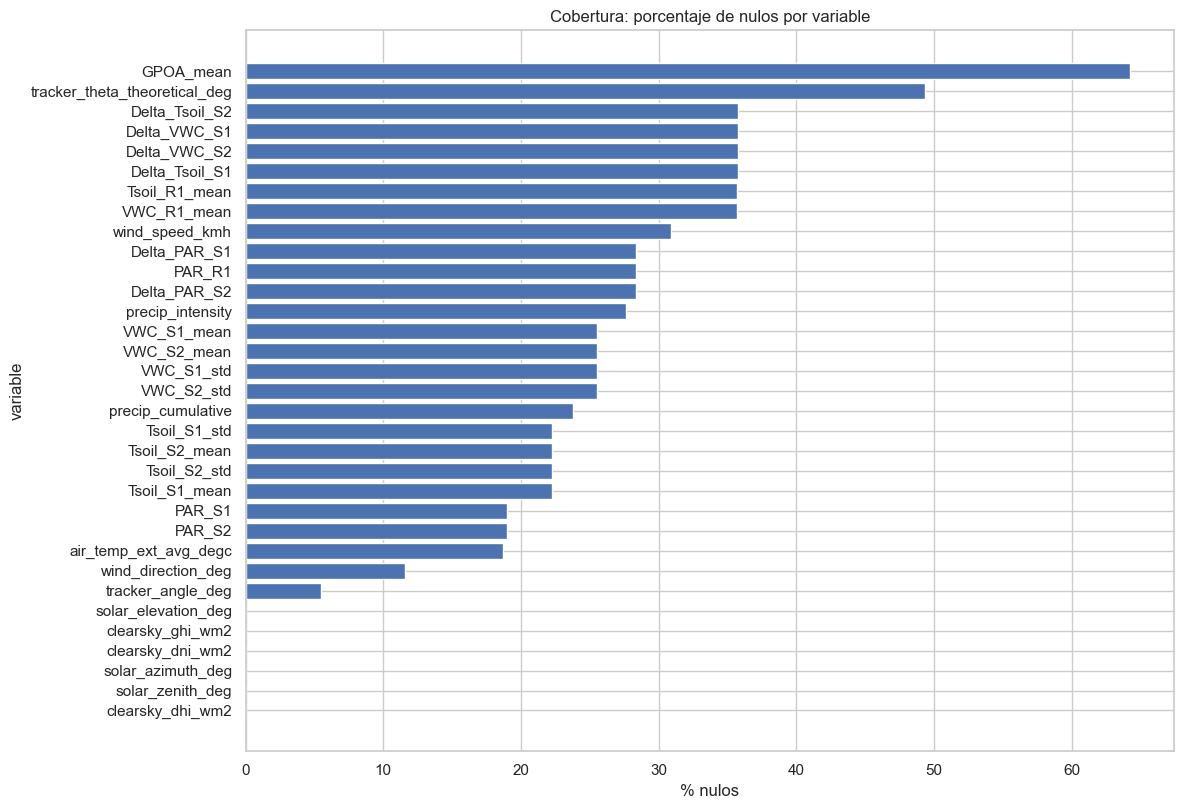

In [3]:
# 1) Porcentaje de nulos por variable
plot_df = summary.sort_values('pct_null', ascending=True)

plt.figure(figsize=(12, max(6, len(plot_df) * 0.25)))
plt.barh(plot_df['variable'], plot_df['pct_null'])
plt.xlabel('% nulos')
plt.ylabel('variable')
plt.title('Cobertura: porcentaje de nulos por variable')
plt.tight_layout()
plt.savefig(OUT_DIR / 'coverage_missing_pct.png', dpi=150, bbox_inches='tight')
plt.show()


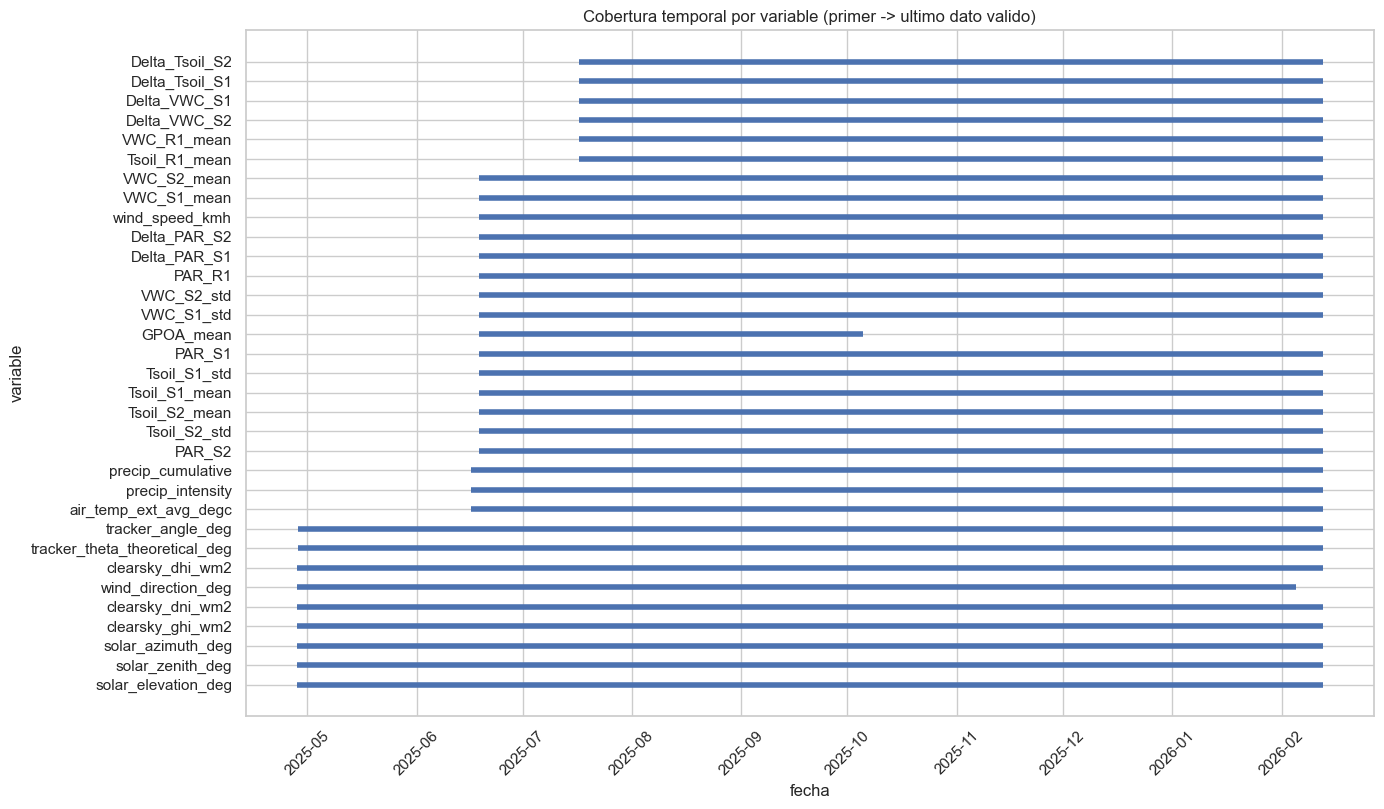

In [4]:
# 2) Ventana de disponibilidad (primer/ultimo dato valido)
coverage = summary.dropna(subset=['first_valid', 'last_valid']).copy()
coverage = coverage.sort_values('first_valid')

fig, ax = plt.subplots(figsize=(14, max(6, len(coverage) * 0.25)))
for i, row in enumerate(coverage.itertuples(index=False)):
    ax.hlines(i, row.first_valid, row.last_valid, linewidth=4)

ax.set_yticks(range(len(coverage)))
ax.set_yticklabels(coverage['variable'])
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.xticks(rotation=45)
ax.set_title('Cobertura temporal por variable (primer -> ultimo dato valido)')
ax.set_xlabel('fecha')
ax.set_ylabel('variable')
plt.tight_layout()
plt.savefig(OUT_DIR / 'coverage_time_windows.png', dpi=150, bbox_inches='tight')
plt.show()


In [6]:
# 4) Variables con huecos maximos largos (> 7 dias)
threshold = pd.Timedelta(days=7)
gaps = summary.copy()
gaps = gaps[gaps['max_gap'].notna()]
gaps = gaps[gaps['max_gap'] > threshold].sort_values('max_gap', ascending=False)

display(gaps[['variable', 'pct_null', 'median_interval', 'max_gap', 'first_valid', 'last_valid']])
gaps.to_csv(OUT_DIR / 'coverage_long_gaps_over_7d.csv', index=False)
print(f'Guardado: {OUT_DIR / "coverage_long_gaps_over_7d.csv"}')


,variable,pct_null,median_interval,max_gap,first_valid,last_valid
11,PAR_R1,28.40,0 days 00:00:30,27 days 06:00:00,2025-06-18 14:00:00,2026-02-12 14:20:00
9,Delta_PAR_S2,28.40,0 days 00:00:30,27 days 06:00:00,2025-06-18 14:00:00,2026-02-12 14:20:00
10,Delta_PAR_S1,28.40,0 days 00:00:30,27 days 06:00:00,2025-06-18 14:00:00,2026-02-12 14:20:00
25,wind_direction_deg,11.55,0 days 00:00:30,22 days 12:00:00,2025-04-28 02:00:00,2026-02-05 01:00:00
8,wind_speed_kmh,30.89,0 days 00:00:30,13 days 00:00:00,2025-06-18 14:00:00,2026-02-12 14:20:00
6,VWC_R1_mean,35.71,0 days 00:00:30,10 days 18:00:00,2025-07-17 02:00:00,2026-02-12 14:20:00
7,Tsoil_R1_mean,35.71,0 days 00:00:30,10 days 18:00:00,2025-07-17 02:00:00,2026-02-12 14:20:00
5,Delta_VWC_S2,35.80,0 days 00:00:30,10 days 18:00:00,2025-07-17 02:00:00,2026-02-12 14:20:00
4,Delta_VWC_S1,35.80,0 days 00:00:30,10 days 18:00:00,2025-07-17 02:00:00,2026-02-12 14:20:00
3,Delta_Tsoil_S1,35.80,0 days 00:00:30,10 days 18:00:00,2025-07-17 02:00:00,2026-02-12 14:20:00


Guardado: \\wsl.localhost\Ubuntu\home\pablo_laptop\GIA\PIA\PIA_lab\sprint3\outputs\coverage_long_gaps_over_7d.csv
